In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/goodreads_library_export.csv")

read = df[df["Exclusive Shelf"] == "read"].copy()
unread = df[~df["Exclusive Shelf"].isin(["read", "currently-reading"])].copy()

read["Date Read"]  = pd.to_datetime(read["Date Read"],  errors="coerce")
read["Date Added"] = pd.to_datetime(read["Date Added"], errors="coerce")
read["My Rating"] = read["My Rating"].replace(0, np.nan)

print(f"Read:   {len(read)}")
print(f"Unread: {len(unread)}")
print(f"Ratio:  {len(unread) / len(read):.1f} unread per book read")

Read:   291
Unread: 1498
Ratio:  5.1 unread per book read


In [2]:
print(f"With a read date: {read['Date Read'].notna().sum()}")
print(f"Missing:          {read['Date Read'].isna().sum()}")

print(read["Date Read"].dt.year.value_counts().sort_index())

With a read date: 291
Missing:          0
Date Read
2014     2
2015     4
2016     8
2017     3
2018     1
2019     1
2020    19
2021    72
2022    59
2023    21
2024    53
2025    28
2026    20
Name: count, dtype: int64


In [3]:
modern = read[read["Date Read"].dt.year >= 2020].copy()
modern["year"]  = modern["Date Read"].dt.year
modern["month"] = modern["Date Read"].dt.to_period("M")

print(f"Books from 2020 onward: {len(modern)}")
print()

yearly = modern.groupby("year").agg(
    books=("Title", "count"),
    mean_pages=("Number of Pages", "mean"),
    mean_rating=("My Rating", "mean"),
)

yearly["total_pages"] = modern.groupby("year")["Number of Pages"].sum()

print(yearly.round(1))

Books from 2020 onward: 272

      books  mean_pages  mean_rating  total_pages
year                                             
2020     19       334.2          4.4       6349.0
2021     72       344.7          4.3      24818.0
2022     59       293.0          4.4      17286.0
2023     21       235.2          4.2       4940.0
2024     53       294.1          4.3      15585.0
2025     28       306.8          4.1       8589.0
2026     20       406.5          4.2       8130.0


In [4]:
# Enhanced columns (added by Enhance-GoodReads-Export tool):
# genres, category (fiction/nonfiction), avg_rating, n_ratings, read_dates
def parse_genres(s):
    if not isinstance(s, str) or not s:
        return []
    return [g.split("|")[0].split(",")[0] for g in s.split(";")]

read["genre_list"] = read["genres"].apply(parse_genres)
read["top_genre"] = read["genre_list"].str[0]
read["avg_rating"] = pd.to_numeric(read["avg_rating"], errors="coerce")
read["n_ratings"] = pd.to_numeric(read["n_ratings"], errors="coerce")

print(f"With genres:     {read['genres'].notna().sum()} of {len(read)}")
print(f"With avg rating: {read['avg_rating'].notna().sum()} of {len(read)}")
print()
print(read["top_genre"].value_counts().head(15))


With genres:     291 of 291
With avg rating: 291 of 291

top_genre
Fiction               69
Fantasy               57
Non Fiction           30
Classics              24
Historical Fiction    15
Young Adult           13
Romance               10
Sci Fi                10
Short Stories          8
Philosophy             7
Graphic Novels         6
Science Fiction        6
Plays                  4
Science                3
Star Wars              3
Name: count, dtype: int64


In [5]:
# category comes from the tool: Goodreads' own Fiction/Nonfiction shelf votes,
# falling back to genre keywords. Blank = couldn't decide.
unknown = read[read["category"].isna()]
print(f"Unclassified: {len(unknown)}")
print(unknown[["Book Id", "Title", "genres"]].to_string())

# Fix wrong or missing ones by hand: Book Id -> "fiction" / "nonfiction"
overrides = {
    # 12345678: "nonfiction",
}
for book_id, cat in overrides.items():
    read.loc[read["Book Id"] == book_id, "category"] = cat

print()
print(read["category"].value_counts(dropna=False))


Unclassified: 0
Empty DataFrame
Columns: [Book Id, Title, genres]
Index: []

category
fiction       228
nonfiction     63
Name: count, dtype: int64


In [6]:
# How do my ratings compare with the Goodreads crowd?
read["vs_crowd"] = read["My Rating"] - read["avg_rating"]
print(read.groupby("category")["vs_crowd"].agg(["mean", "count"]).round(2))


            mean  count
category               
fiction     0.13    228
nonfiction  0.17     63


In [7]:
modern = read[read["Date Read"].dt.year >= 2020].copy()
modern["year"] = modern["Date Read"].dt.year

# Books of each category per year
print(pd.crosstab(modern["year"], modern["category"]))
print()

# As row proportions, so years with different totals compare fairly.
# normalize="index" divides each row by its own total.
print(pd.crosstab(modern["year"], modern["category"], normalize="index").round(2))

category  fiction  nonfiction
year                         
2020           13           6
2021           63           9
2022           45          14
2023           12           9
2024           44           9
2025           19           9
2026           16           4

category  fiction  nonfiction
year                         
2020         0.68        0.32
2021         0.88        0.12
2022         0.76        0.24
2023         0.57        0.43
2024         0.83        0.17
2025         0.68        0.32
2026         0.80        0.20


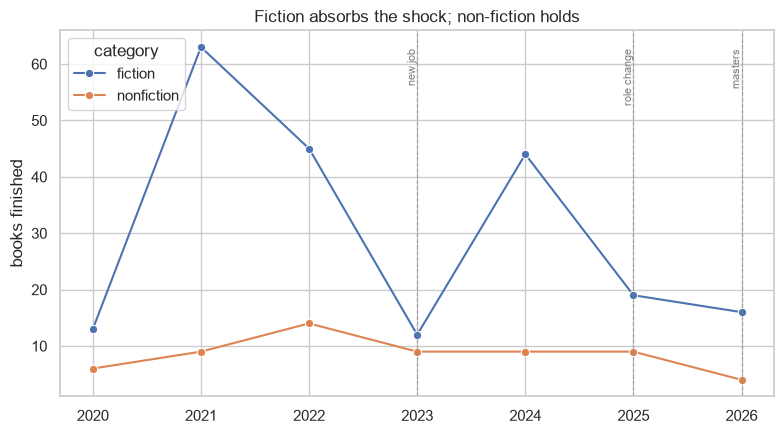

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Reshape from wide (one column per category) to long (one row per
# year-category pair) — seaborn wants long format for grouped plots.
by_year = (
    modern.groupby(["year", "category"])
    .size()
    .reset_index(name="books")
)

fig, ax = plt.subplots(figsize=(8, 4.5))

sns.lineplot(data=by_year, x="year", y="books", hue="category",
             marker="o", ax=ax)

# Mark the transitions — the annotations are the argument, not decoration
for yr, label in [(2023, "new job"), (2025, "role change"), (2026, "masters")]:
    ax.axvline(yr, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    ax.text(yr, ax.get_ylim()[1] * 0.95, label, rotation=90,
            va="top", ha="right", fontsize=8, color="grey")

ax.set_xlabel("")
ax.set_ylabel("books finished")
ax.set_title("Fiction absorbs the shock; non-fiction holds")

plt.tight_layout()
plt.savefig("../output/books_by_category.png", dpi=150)
plt.show()

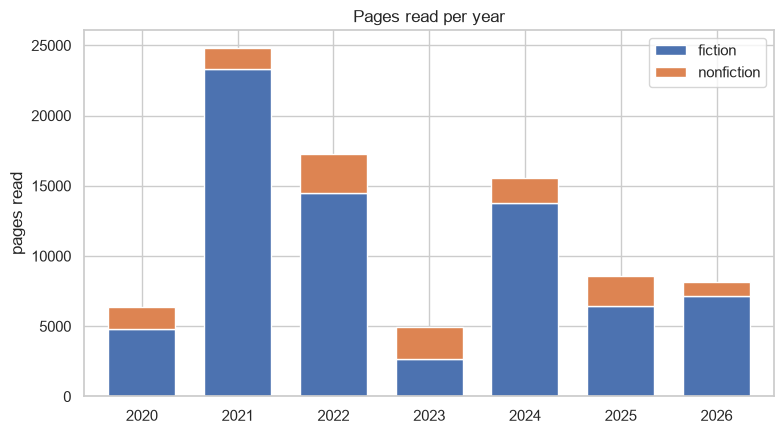

In [9]:
# Total pages per year by category. Book count understates the 2023 drop
# because the books that year were also shorter.
pages = (
    modern.dropna(subset=["Number of Pages"])
    .groupby(["year", "category"])["Number of Pages"]
    .sum()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 4.5))

# Stacked bars: the two categories sum to the year's total, so you can
# read both the composition and the overall level from one chart.
pivot = pages.pivot(index="year", columns="category", values="Number of Pages")
pivot.plot(kind="bar", stacked=True, ax=ax, width=0.7)

ax.set_xlabel("")
ax.set_ylabel("pages read")
ax.set_title("Pages read per year")
ax.legend(title="")
plt.xticks(rotation=0)

plt.tight_layout()
plt.savefig("../output/pages_by_category.png", dpi=150)
plt.show()

In [10]:
print(f"Missing page count: {modern['Number of Pages'].isna().sum()} of {len(modern)}")

Missing page count: 0 of 272
